# Week 4 · FT-Transformer Model
Business Rehearsal Outcome Predictor · Spring 2026

Feature Tokenizer + Transformer encoder. Each feature is projected to a shared
embedding space; self-attention learns cross-feature interactions that Ridge
and XGBoost cannot capture directly.

> **Training time**: ~1–3 min on CPU/MPS for 150 epochs across 3 targets.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 4), 'axes.spines.top': False, 'axes.spines.right': False})
from models.transformer_model import (
    load_features, temporal_split, train_transformer, print_results
)


In [2]:
df = load_features('data/processed/training_data.csv')
train, test = temporal_split(df)
results = train_transformer(train, test)
print_results(results)


Loaded 2,100 rows from data/processed/training_data.csv
  Date range: 2025-11-30 → 2026-08-17
  Businesses: 150
  Branches:   2,100

Temporal split at 2026-06-26 (80%/20%)
  Train rows: 1,677  |  Test rows: 423

Training: inventory  (73 features, device=mps)
  epoch    1  loss=16967.0158  val_mape=157.4%  best=157.4%
  epoch   20  loss=2433.8893  val_mape=48.5%  best=48.5%
  epoch   40  loss=1491.8819  val_mape=40.8%  best=36.3%
  epoch   60  loss=314.3903  val_mape=31.0%  best=30.5%
  epoch   80  loss=242.7978  val_mape=34.4%  best=30.1%
  epoch  100  loss=152.8122  val_mape=32.8%  best=29.7%
  early stop at epoch 115  (no improvement for 20 epochs)

Training: cashflow  (73 features, device=mps)
  epoch    1  loss=55125478.8575  val_mape=99.9%  best=99.9%
  epoch   20  loss=52703702.4168  val_mape=171.5%  best=99.6%
  early stop at epoch 23  (no improvement for 20 epochs)

Training: order_velocity  (73 features, device=mps)
  epoch    1  loss=261.8416  val_mape=147.9%  best=147.9%
  e

## Predicted vs actual

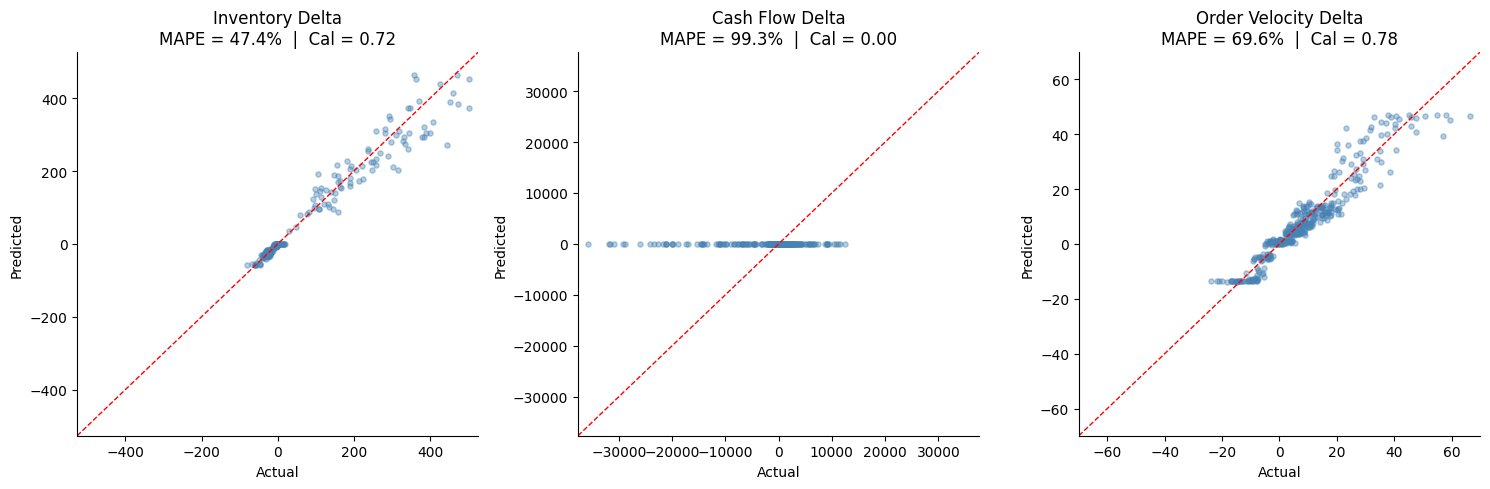

In [3]:
labels = {
    'label_inventory_delta':      'Inventory Delta',
    'label_cashflow_delta':       'Cash Flow Delta',
    'label_order_velocity_delta': 'Order Velocity Delta',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (target, r) in zip(axes, results.items()):
    ax.scatter(r['y_test'], r['y_pred'], alpha=0.4, s=14, color='steelblue')
    lim = max(np.abs(r['y_test']).max(), np.abs(r['y_pred']).max()) * 1.05
    ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title(f"{labels[target]}\nMAPE = {r['mape']:.1f}%  |  Cal = {r['calibration']:.2f}")
plt.tight_layout()
plt.show()


## Prediction intervals — sample of 60 test points
Intervals from the joint quantile head (lower_10 / upper_90 outputs).

In [ ]:
N = 60
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (target, r) in zip(axes, results.items()):
    idx    = np.argsort(r['y_pred'])[:N]
    pred   = r['y_pred'][idx]
    actual = r['y_test'][idx]
    lower  = r['y_lower'][idx]
    upper  = r['y_upper'][idx]
    yerr   = [np.maximum(pred - lower, 0), np.maximum(upper - pred, 0)]
    ax.errorbar(range(N), pred, yerr=yerr, fmt='none',
                ecolor='#aec6e8', elinewidth=1.2, capsize=0)
    ax.scatter(range(N), actual, s=12, color='steelblue', zorder=3, label='actual')
    ax.scatter(range(N), pred,   s=12, color='darkorange', zorder=3,
               label='predicted', marker='+')
    ax.set_xlabel('Test sample (sorted by prediction)')
    ax.set_ylabel('Value')
    ax.set_title(labels[target].replace(' Delta', ''))
    ax.legend(fontsize=8)
plt.suptitle('Transformer: 80% prediction intervals (sample)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
